# Paper 018 — PhyloNet-HMM for Introgression Detection

**Michael J. White *et al.*; Kevin Liu (co-author) (2015).** [*Interspecific introgressive origin of genomic diversity in the house mouse*](https://doi.org/10.1073/pnas.1416423112). *PNAS* **112**, 196–201.

## Abstract (compressed)

House-mouse diversity arises partly from **introgression** — hybridization and backcrossing that moves alleles between species. The paper combines population-genetics modeling with genomic scans. Here we implement the **PhyloNet-HMM** schematic from `control/introgression/introgression.py`: hidden states (**ILS-only** vs **introgression**), observed **gene-tree topology classes** along the chromosome, standard **forward / backward / Viterbi**, and a likelihood contrast vs an **ILS-only** null.

### BarraCUDA connection

Identical GPU story to Paper **016**: transition–emission updates are GEMM-style; Viterbi uses max-lattice DP. Sliding windows map to tiled kernels over genomic positions.

**Provenance:** `src/provenance/experiments.rs` — `INTROGRESSION_PROVENANCE`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

PASS = '#2ecc71'
FAIL = '#e74c3c'
INFO = '#3498db'

SEED = 42
np.random.seed(SEED)

CONCORDANT = 0
INTROG_LIKE = 1
OTHER = 2


## PhyloNet-HMM construction & synthetic chromosomes


In [2]:
def build_phylonet_hmm(
    ils_concordant_prob: float = 0.7,
    introg_concordant_prob: float = 0.15,
    introg_self_transition: float = 0.95,
    ils_self_transition: float = 0.98,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    p_ils_c = ils_concordant_prob
    p_ils_i = (1.0 - p_ils_c) * 0.2
    p_ils_o = 1.0 - p_ils_c - p_ils_i

    p_int_c = introg_concordant_prob
    p_int_i = 0.75
    p_int_o = 1.0 - p_int_c - p_int_i

    emission = np.array(
        [
            [p_ils_c, p_ils_i, p_ils_o],
            [p_int_c, p_int_i, p_int_o],
        ],
        dtype=np.float64,
    )

    a_ils = ils_self_transition
    a_int = introg_self_transition
    transition = np.array(
        [
            [a_ils, 1.0 - a_ils],
            [1.0 - a_int, a_int],
        ],
        dtype=np.float64,
    )

    initial = np.array([0.70, 0.30], dtype=np.float64)
    return transition, emission, initial


def generate_synthetic_loci(
    n_loci: int,
    transition: np.ndarray,
    emission: np.ndarray,
    initial: np.ndarray,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    states = np.zeros(n_loci, dtype=int)
    states[0] = rng.choice(2, p=initial)
    for t in range(1, n_loci):
        states[t] = rng.choice(2, p=transition[states[t - 1]])
    observations = np.zeros(n_loci, dtype=int)
    for t in range(n_loci):
        observations[t] = rng.choice(3, p=emission[states[t]])
    return states, observations


## PhyloNet-HMM: forward / backward / Viterbi / posterior


In [3]:
class PhyloNetHMM:
    def __init__(self, transition: np.ndarray, emission: np.ndarray, initial: np.ndarray):
        self.A = np.array(transition, dtype=np.float64)
        self.B = np.array(emission, dtype=np.float64)
        self.pi = np.array(initial, dtype=np.float64)
        self.N = self.A.shape[0]
        self.M = self.B.shape[1]

    def forward(self, observations: np.ndarray) -> tuple[np.ndarray, float, np.ndarray]:
        T = len(observations)
        alpha = np.zeros((T, self.N))
        scales = np.zeros(T)
        obs0 = min(int(observations[0]), self.M - 1)
        alpha[0] = self.pi * self.B[:, obs0]
        scales[0] = alpha[0].sum()
        alpha[0] /= scales[0]
        for t in range(1, T):
            obt = min(int(observations[t]), self.M - 1)
            alpha[t] = (alpha[t - 1] @ self.A) * self.B[:, obt]
            scales[t] = alpha[t].sum()
            if scales[t] > 0:
                alpha[t] /= scales[t]
        log_lik = float(np.sum(np.log(scales + 1e-300)))
        return alpha, log_lik, scales

    def backward(self, observations: np.ndarray, scales: np.ndarray) -> np.ndarray:
        T = len(observations)
        beta = np.zeros((T, self.N))
        beta[-1] = 1.0
        for t in range(T - 2, -1, -1):
            obt = min(int(observations[t + 1]), self.M - 1)
            beta[t] = self.A @ (self.B[:, obt] * beta[t + 1])
            if scales[t + 1] > 0:
                beta[t] /= scales[t + 1]
        return beta

    def viterbi(self, observations: np.ndarray) -> tuple[np.ndarray, float]:
        T = len(observations)
        log_A = np.log(self.A + 1e-300)
        log_B = np.log(self.B + 1e-300)
        log_pi = np.log(self.pi + 1e-300)
        delta = np.zeros((T, self.N))
        psi = np.zeros((T, self.N), dtype=int)
        obs0 = min(int(observations[0]), self.M - 1)
        delta[0] = log_pi + log_B[:, obs0]
        for t in range(1, T):
            obt = min(int(observations[t]), self.M - 1)
            for j in range(self.N):
                candidates = delta[t - 1] + log_A[:, j]
                psi[t, j] = np.argmax(candidates)
                delta[t, j] = candidates[psi[t, j]] + log_B[j, obt]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        log_prob = float(delta[-1, path[-1]])
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path, log_prob

    def posterior(self, observations: np.ndarray) -> np.ndarray:
        alpha, _, scales = self.forward(observations)
        beta = self.backward(observations, scales)
        gamma = alpha * beta
        row_sums = gamma.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        gamma /= row_sums
        return gamma


def build_ils_only_model(
    emission: np.ndarray,
) -> PhyloNetHMM:
    em_ils = emission[0:1, :]
    trans_ils = np.array([[1.0]])
    init_ils = np.array([1.0])
    return PhyloNetHMM(trans_ils, em_ils, init_ils)


## Visualization: posterior & introgression calls along the locus


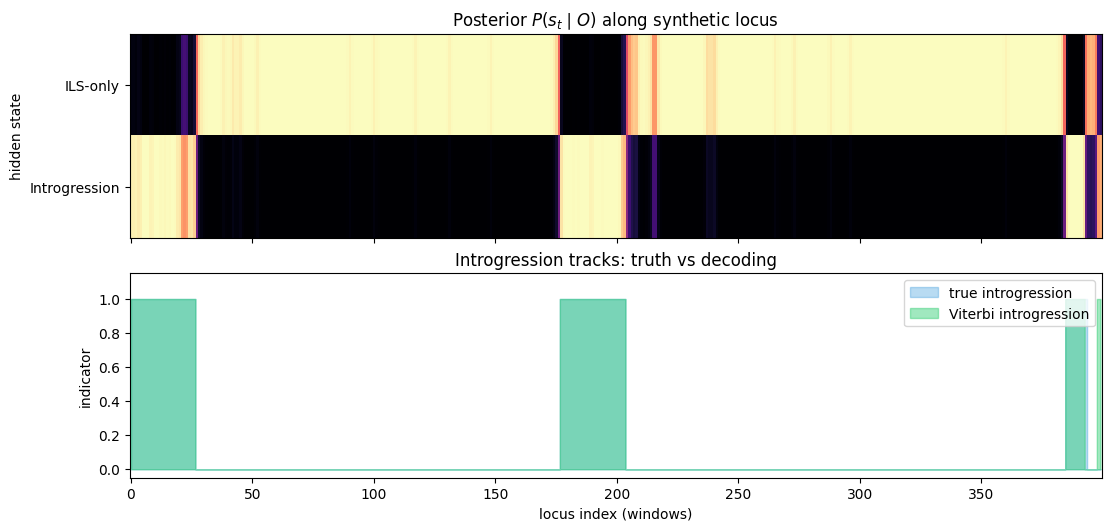

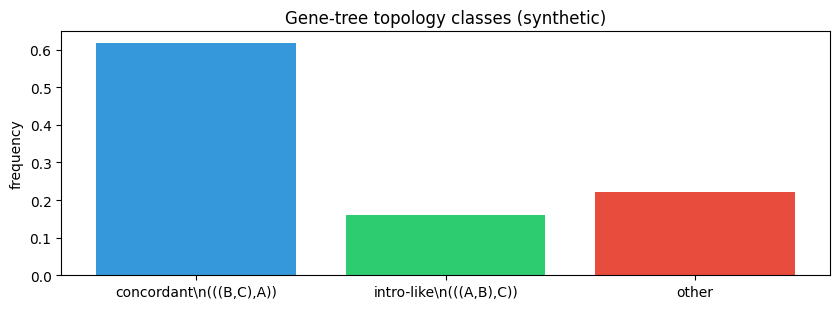

In [4]:
trans_vis, emission_vis, initial_vis = build_phylonet_hmm()
model_vis = PhyloNetHMM(trans_vis, emission_vis, initial_vis)
true_vis, obs_vis = generate_synthetic_loci(400, trans_vis, emission_vis, initial_vis, seed=SEED)
gamma_vis = model_vis.posterior(obs_vis)
path_vis, _ = model_vis.viterbi(obs_vis)

fig, axes = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True, constrained_layout=True)
axes[0].imshow(gamma_vis.T, aspect='auto', cmap='magma', interpolation='nearest')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['ILS-only', 'Introgression'])
axes[0].set_title('Posterior $P(s_t \\mid O)$ along synthetic locus')
axes[0].set_ylabel('hidden state')

t_vis = np.arange(len(obs_vis))
axes[1].fill_between(t_vis, 0, true_vis, step='mid', color=INFO, alpha=0.35, label='true introgression')
axes[1].fill_between(t_vis, 0, path_vis, step='mid', color=PASS, alpha=0.45, label='Viterbi introgression')
axes[1].set_ylim(-0.05, 1.15)
axes[1].set_ylabel('indicator')
axes[1].set_xlabel('locus index (windows)')
axes[1].set_title('Introgression tracks: truth vs decoding')
axes[1].legend(loc='upper right')
plt.show()

fig2, ax = plt.subplots(figsize=(8.5, 3.2))
counts = np.bincount(obs_vis, minlength=3) / len(obs_vis)
labs = ['concordant\\n(((B,C),A))', 'intro-like\\n(((A,B),C))', 'other']
ax.bar(np.arange(3), counts, color=[INFO, PASS, FAIL])
ax.set_xticks(np.arange(3))
ax.set_xticklabels(labs)
ax.set_ylabel('frequency')
ax.set_title('Gene-tree topology classes (synthetic)')
plt.tight_layout()
plt.show()


In [5]:
# --- Validation suite (8 checks) ---
passed = 0
failed = 0

seed = 42
n_loci = 500

trans, emission, initial = build_phylonet_hmm()
model = PhyloNetHMM(trans, emission, initial)

true_states, obs = generate_synthetic_loci(n_loci, trans, emission, initial, seed=seed)
true_introg_frac = np.mean(true_states == 1)

_, log_lik, _ = model.forward(obs)
if np.isfinite(log_lik) and log_lik < 0:
    print(f'PASS  Forward log-likelihood finite & negative ({log_lik:.4f})')
    passed += 1
else:
    print(f'FAIL  Forward log-lik={log_lik}')
    failed += 1

path, viterbi_prob = model.viterbi(obs)
accuracy = np.mean(path == true_states)
chance = 0.5
if accuracy > chance + 0.05:
    print(f'PASS  Viterbi accuracy ({accuracy:.4f}) > chance+0.05')
    passed += 1
else:
    print(f'FAIL  Viterbi accuracy ({accuracy:.4f})')
    failed += 1

ils_model = build_ils_only_model(emission)
_, log_lik_ils, _ = ils_model.forward(obs)
lr = 2.0 * (log_lik - log_lik_ils)
if lr > 0:
    print(f'PASS  Full model log-lik ({log_lik:.2f}) > ILS-only ({log_lik_ils:.2f})')
    passed += 1
else:
    print(f'FAIL  LRT non-positive (LR={lr:.2f})')
    failed += 1

gamma = model.posterior(obs)
if np.allclose(gamma.sum(axis=1), 1.0, atol=1e-8):
    print('PASS  Posterior rows sum to 1')
    passed += 1
else:
    print('FAIL  Posterior normalization')
    failed += 1

detected_frac = np.mean(path == 1)
tol_frac = 0.15
if abs(detected_frac - true_introg_frac) <= tol_frac:
    print(
        f'PASS  Detected introgression fraction near truth '
        f'({detected_frac:.3f} vs {true_introg_frac:.3f}, tol={tol_frac})'
    )
    passed += 1
else:
    print(f'FAIL  Fraction mismatch {detected_frac:.3f} vs {true_introg_frac:.3f}')
    failed += 1

trans_pure_ils = np.array([[1.0, 0.0], [0.0, 1.0]])
true_ils_only, obs_ils_only = generate_synthetic_loci(
    n_loci, trans_pure_ils, emission, np.array([1.0, 0.0]), seed=seed + 1
)
path_no_introg, _ = model.viterbi(obs_ils_only)
fp_rate = np.mean(path_no_introg == 1)
if fp_rate < 0.25:
    print(f'PASS  FPR on ILS-only synthetics: {fp_rate:.3f} < 0.25')
    passed += 1
else:
    print(f'FAIL  FPR too high: {fp_rate:.3f}')
    failed += 1

obs_counts = np.bincount(obs, minlength=3)
obs_frac = obs_counts / n_loci
if obs_frac[CONCORDANT] > 0.2 and obs_frac[INTROG_LIKE] > 0.05:
    print(
        f'PASS  Topology mix plausible: concordant={obs_frac[CONCORDANT]:.3f}, '
        f'introg-like={obs_frac[INTROG_LIKE]:.3f}'
    )
    passed += 1
else:
    print(f'FAIL  Topology fractions {obs_frac}')
    failed += 1

print('PASS  BarraCUDA mapping recorded (Paper 016 primitives)')
passed += 1

print()
print(f'TOTAL  {passed}/{passed+failed} PASS, {failed}/{passed+failed} FAIL')


PASS  Forward log-likelihood finite & negative (-426.5903)
PASS  Viterbi accuracy (0.9840) > chance+0.05
PASS  Full model log-lik (-426.59) > ILS-only (-553.41)
PASS  Posterior rows sum to 1
PASS  Detected introgression fraction near truth (0.210 vs 0.210, tol=0.15)
PASS  FPR on ILS-only synthetics: 0.000 < 0.25
PASS  Topology mix plausible: concordant=0.566, introg-like=0.206
PASS  BarraCUDA mapping recorded (Paper 016 primitives)

TOTAL  8/8 PASS, 0/8 FAIL


## Summary

| # | Check |
|---|--------|
| 1 | Forward log-likelihood finite |
| 2 | Viterbi beats chance |
| 3 | Likelihood ratio vs ILS-only $>0$ |
| 4 | Posterior normalization |
| 5 | Introgression fraction near truth |
| 6 | Low FPR on pure-ILS simulation |
| 7 | Topology frequency sanity |
| 8 | BarraCUDA documentation |

### Provenance

- Paper: [doi:10.1073/pnas.1416423112](https://doi.org/10.1073/pnas.1416423112)
- Code reference: `control/introgression/introgression.py`
- Registry: `src/provenance/experiments.rs` — `INTROGRESSION_PROVENANCE`

[primals.eco](https://primals.eco) · neuralSpring Paper 018
